# Plot picks 

This notebook is used to plot the waveforms within a window.
The window is predefined. 

Agentic AI was used in this notebook.

by Hiroto Bito 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import obspy
from obspy import read
from obspy.core import UTCDateTime
from obspy.core.stream import Stream
from obspy.clients.fdsn.client import Client
import numpy as np
import time
import os
from tqdm import tqdm
import sys

parent_dir = '/home/hbito/cascadia_obs_ensemble/utils'
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from data_client import get_waveforms

In [2]:
path_assigned_picks_df = '/wd1/hbito_data/data/datasets_all_regions/Cascadia_updated_catalog_picks_assignment_ver_3.csv'
assigned_picks_df = pd.read_csv(path_assigned_picks_df)
assigned_picks_df.head(10)

,Unnamed: 0,time_pick,station,phase,timeres,idx,arid,latitude,longitude,depth,Detection Value,time,RMS Residual (s),Num. P,Num. S,picks,slatitude,slongitude,selevation
0,0,2010-01-01T00:15:27.180000Z,UW.PCMD,P,0.049,0,0,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0
1,1,2010-01-01T00:15:37.840400Z,UW.RVW,P,1.264,0,1,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.149750,-122.742996,504.0
2,2,2010-01-01T00:15:33.280000Z,UW.PCMD,S,-0.243,0,2,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.888962,-122.301483,239.0
3,3,2010-01-01T00:15:42.002000Z,UW.GNW,S,2.402,0,3,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.564130,-122.824980,220.0
4,4,2010-01-01T00:15:43.618400Z,PB.B013,S,-0.651,0,4,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813000,-122.910797,75.3
5,5,2010-01-01T00:15:43.768400Z,PB.B943,S,-0.511,0,5,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,47.813202,-122.911301,84.2
6,6,2010-01-01T00:15:48.060400Z,UW.BOW,S,-0.263,0,6,47.13396,-122.09098,60.147,0.68,2010-01-01 00:15:16.204000+00:00,1.081,2,5,7,46.474831,-123.229301,870.0
7,7,2010-01-01T00:17:04.730000Z,UW.PASS,P,-0.499,1,7,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.998299,-122.085197,175.4
8,8,2010-01-01T00:17:05.008400Z,PB.B943,P,-0.252,1,8,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,47.813202,-122.911301,84.2
9,9,2010-01-01T00:17:05.020400Z,UW.BLN,P,0.415,1,9,48.17742,-121.83289,6.163,0.84,2010-01-01 00:16:49.343000+00:00,0.985,25,30,55,48.006624,-122.972646,601.0


In [3]:
path_plots = '/wd1/hbito_data/data/datasets_all_regions/plot_picks_reloc_cog_ver3/'

In [4]:
os.makedirs(path_plots, exist_ok=True)

Define the plotting function

In [5]:
# Function to plot waveforms for the first 100 picks using Obspy bulk request
 
def plot_waveforms_for_picks(assigned_picks_df, path_plots, window_before=30, window_after=120, n_picks=100, source='pnwstore', scaling_factor_vline=0.1):
    
    # Prepare bulk request list: (network, station, location, channel, starttime, endtime)
    bulk = []
    pick_info = []
    ls_idx = np.random.choice(a=len(assigned_picks_df), size=(n_picks))

    
    # for i, row in assigned_picks_df.head(n_picks).iterrows():
    for i in range(len(ls_idx)):
        orid = assigned_picks_df.iloc[ls_idx[i]]['idx']
        pick_id = assigned_picks_df.iloc[ls_idx[i]]['arid']
      
        date, _time = assigned_picks_df.iloc[ls_idx[i]]['time'].split(' ')
        datetime_str = date+'T'+_time
        origin_time = UTCDateTime(datetime_str)  # Accept ISO string directly
        latitude = assigned_picks_df.iloc[ls_idx[i]]['latitude']
        longitude = assigned_picks_df.iloc[ls_idx[i]]['longitude']
        depth = assigned_picks_df.iloc[ls_idx[i]]['depth']
        
        # You may need to adjust these fields to match your DataFrame columns
        network = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[0].strip()
        station = assigned_picks_df.iloc[ls_idx[i]]['station'].split('.')[1].strip()
        location = '*'
        channel = "*H*"
        starttime = origin_time - window_before 
        endtime = origin_time + window_after
        time_pick = assigned_picks_df.iloc[ls_idx[i]]['time_pick']
        time_pick_origin  = UTCDateTime(assigned_picks_df.iloc[ls_idx[i]]['time_pick']) - origin_time
        phase = assigned_picks_df.iloc[ls_idx[i]]['phase']

        bulk.append((network, station, location, channel, starttime, endtime))
        pick_info.append({
            'orid': orid,
            'pick_id': pick_id,
            'origin_time': origin_time,
            'latitude': latitude,
            'longitude': longitude,
            'depth': depth,
            'network': network,
            'station': station,
            'location': location,
            'channel': channel,
            'starttime': starttime,
            'endtime': endtime,
            'time_pick': time_pick,
            'time_pick_origin': time_pick_origin,
            'phase': phase
        })


    # Parameters to process waveforms
    new_sampling_rate = 100 # in Hz
    # freqmax = 15 # in Hz
    # freqmin = 4 # in Hz
    freq_highpass = 2 # in Hz


    # Plotting
    for i, info in enumerate(pick_info):

        network = pick_info[i]['network']
        station = pick_info[i]['station']
        channel = pick_info[i]['channel']
        starttime = pick_info[i]['starttime']
        endtime = pick_info[i]['endtime']

        time_pick = pick_info[i]['time_pick']        
        time_pick_origin = pick_info[i]['time_pick_origin']

        time.sleep(0.1)

        try:
            st = get_waveforms(network=network, station=station, channel=channel,
                                starttime=starttime, endtime=endtime,
                                source=source)
        except Exception as e:
            print(f"Request failed: {e}")
            st = Stream()

        time.sleep(0.1)


        fig, ax = plt.subplots(figsize=(10, 4))

         # Create a new stream
        sdata = Stream()
        
        # Check if loaded data have a vertical component (minimum requirement)
        has_Z = bool(st.select(id=f'{network}.{station}..??Z'))
        # Check for HH and BH channels presence
        has_HH = bool(st.select(id=f'{network}.{station}..HH?'))
        has_BH = bool(st.select(id=f'{network}.{station}..BH?'))
        has_EH = bool(st.select(id=f'{network}.{station}..EH?'))

        if not has_Z:
            print(f'No Vertical Component Data Present at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick}. Skipping')
            continue

        # Apply selection logic based on channel presence
        if has_HH:
            # If all HH, BH, and EH, channels are present, select only HH
            sdata += st.select(id=f'{network}.{station}..HHZ')
        elif has_BH:
            # If BH and EH channels are present, select only BH
            sdata += st.select(id=f'{network}.{station}..BHZ')
        elif has_EH:
            # If only EH channels are present, select only EH
            # NTS: This may result in getting only vertical component data - EH? is used for PNSN analog stations
            # NTS: This may also be tricky for pulling full day-volumes because the sampling rate shifts for
            #      analog stations due to the remote digitization scheme used with analog stations
            sdata += st.select(id=f'{network}.{station}..EHZ')
        else:
            print(f'No data available at {network}.{station} with HHZ, BHZ or EHZ channels at {time_pick}. Skipping.')
            continue

        tr = sdata[0]

        # Resample
        tr.resample(new_sampling_rate)
            
        # Apply highpass filter
        tr.detrend(type='demean')
        tr.taper(max_percentage=0.05)
        tr.filter(type='highpass', freq=freq_highpass)
        # tr.filter(type='bandpass', freqmin=freqmin, freqmax=freqmax)
            

        times = np.linspace(-window_before, window_after, tr.stats.npts)
        time_vline = time_pick_origin
        data = tr.data

        # Parameters to draw the vertical lines to indicate picks
        ymax = np.max(np.abs(data))*scaling_factor_vline
        ymin = (-1) * np.max(np.abs(data))*scaling_factor_vline

        ax.plot(times, data)
        ax.vlines(time_vline, ymin, ymax, color='k', linestyles='solid')
        ax.set_title(f"Origin ID: {info['orid']} | Pick ID: {info['pick_id']} | Network: {info['network']} | Station: {info['station']} | Phase: {info['phase']}")
        ax.set_xlabel(f"Time (s) from Origin Time")
        ax.set_ylabel("Amplitude")
        ax.grid()

        # Set the ticks on the x axis
        ticks = np.arange(-window_before, window_after, 10)
        str_ticks = [str(t) for t in ticks]

        ax.set_xticks(ticks=ticks, labels=str_ticks)

        # Annotate event info
        info_text = (f"Origin Time: {info['origin_time']}\n"
                     f"Latitude: {info['latitude']}\n"
                     f"Longitude: {info['longitude']}\n"
                     f"Depth: {info['depth']}")
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.98, 0.98, info_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', horizontalalignment='right', bbox=props)
        plt.tight_layout()
        plt.show()
        fig.savefig(path_plots+f"waveform_plot_orid_{info['orid']}_arid_{info['pick_id']}.png")
        plt.close(fig)
        time.sleep(0.1)


Create the waveform plots

In [6]:
# Define the variables in the function
window_before = 30 # in sec
window_after = 150 # in sec
n_picks = 40
source = 'pnwstore'
scaling_factor_vline = 0.3
path_plots = path_plots

No Vertical Component Data Present at BK.JCC with HHZ, BHZ or EHZ channels at 2014-09-19T04:13:50.658393Z. Skipping
No Vertical Component Data Present at NC.KOM with HHZ, BHZ or EHZ channels at 2014-10-05T08:13:56.027700Z. Skipping


PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


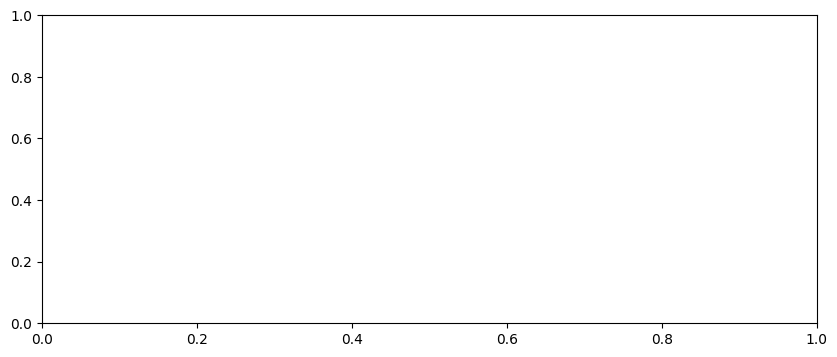

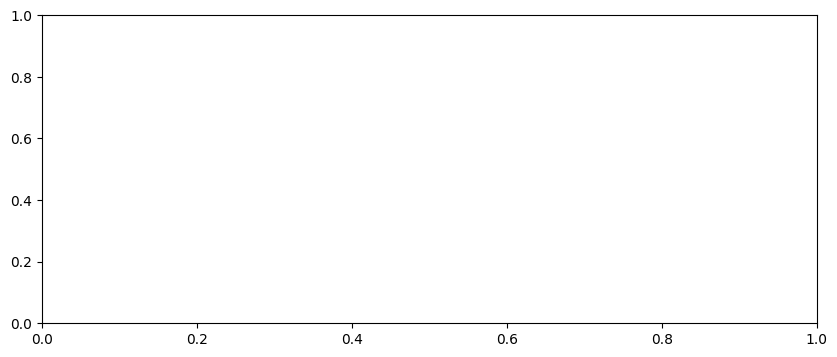

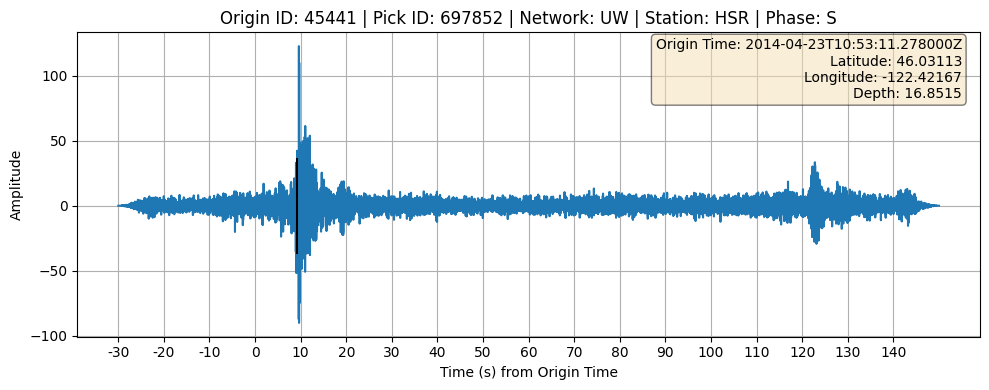

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


No Vertical Component Data Present at NC.KOM with HHZ, BHZ or EHZ channels at 2014-07-06T22:51:38.577700Z. Skipping


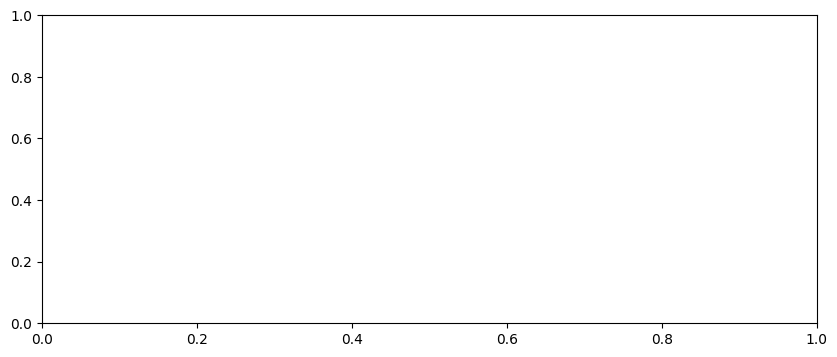

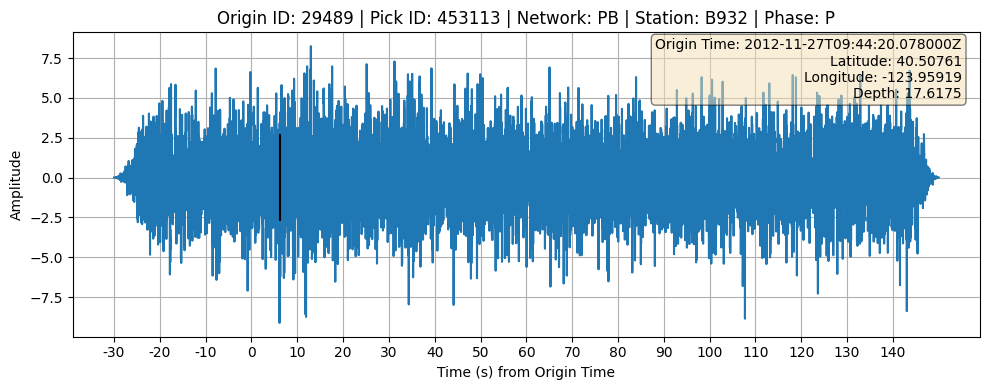

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


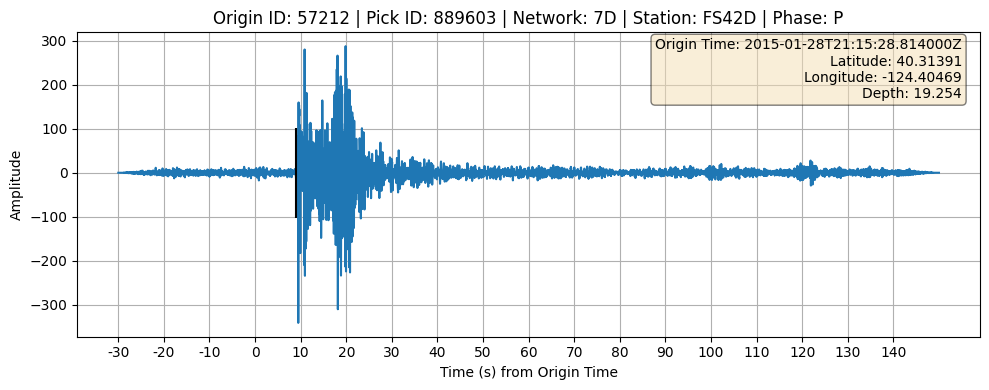

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


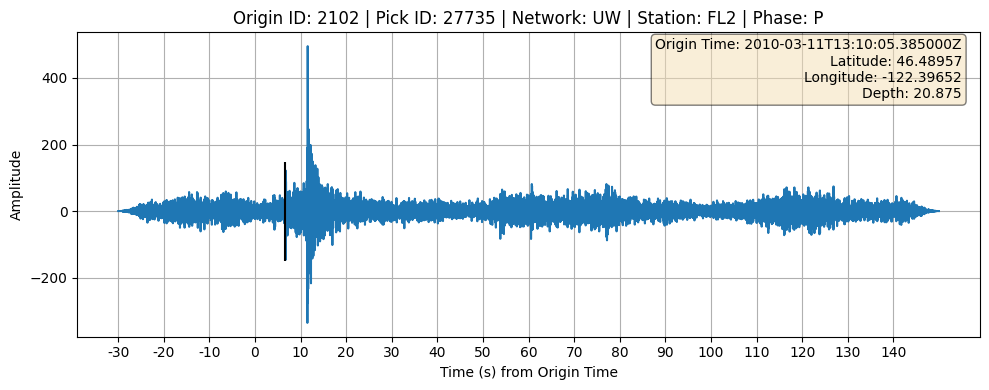

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


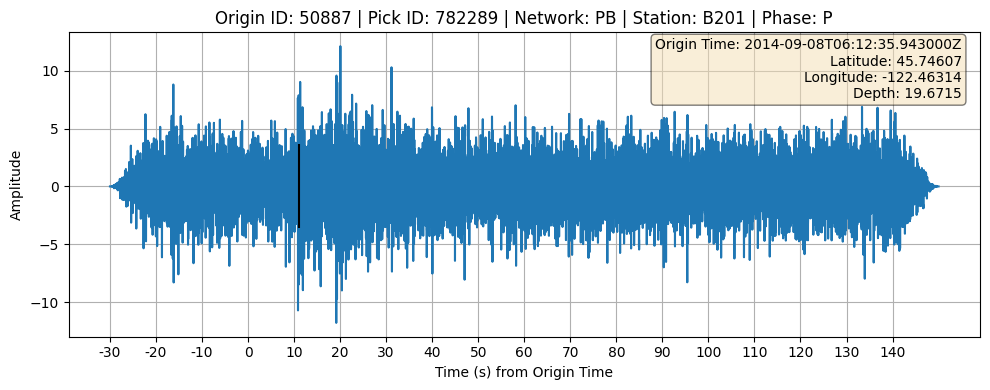

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


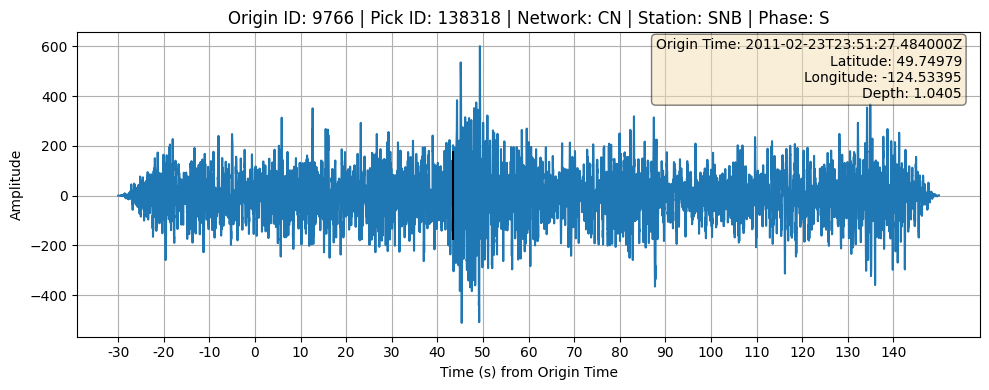

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


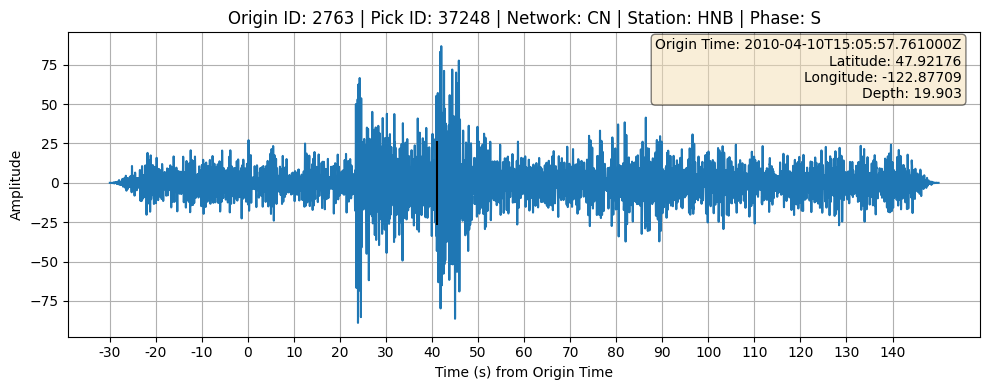

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


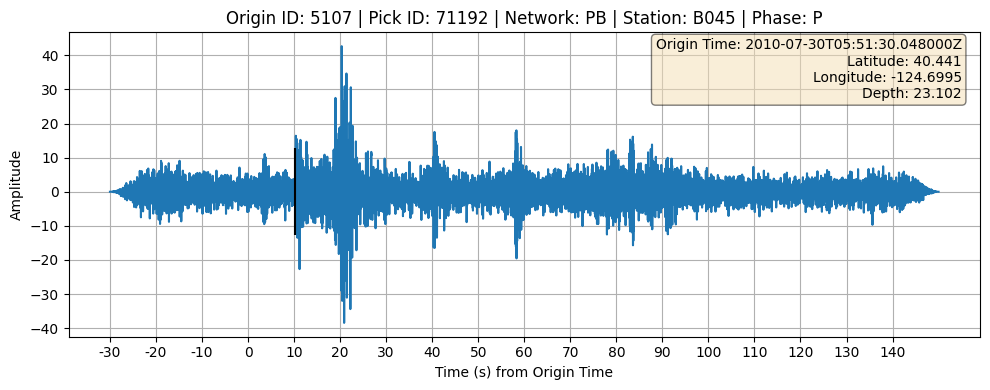

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


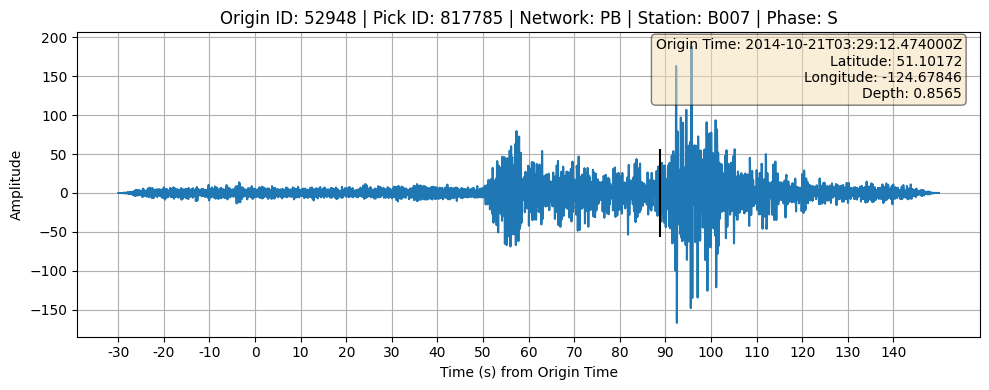

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


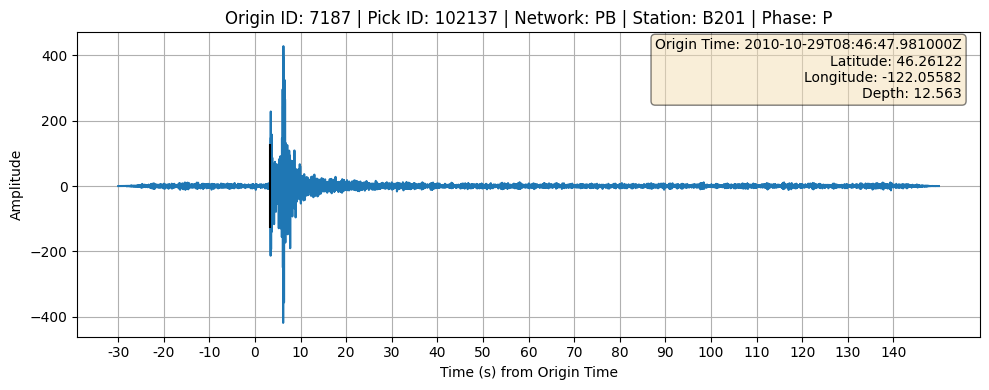

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


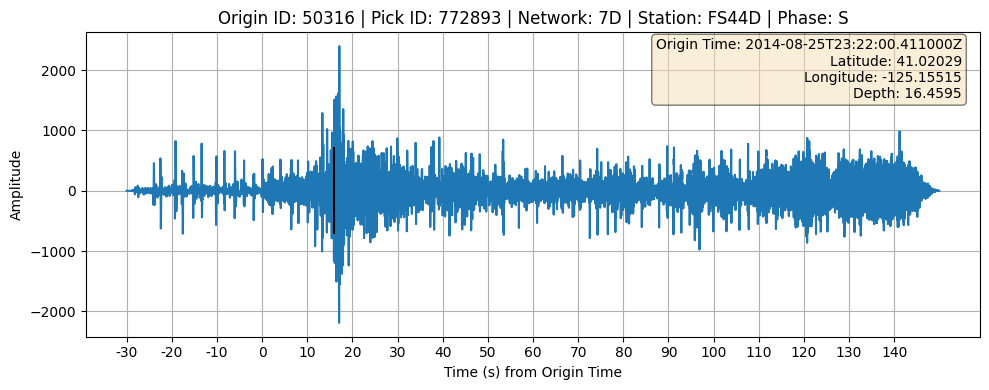

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


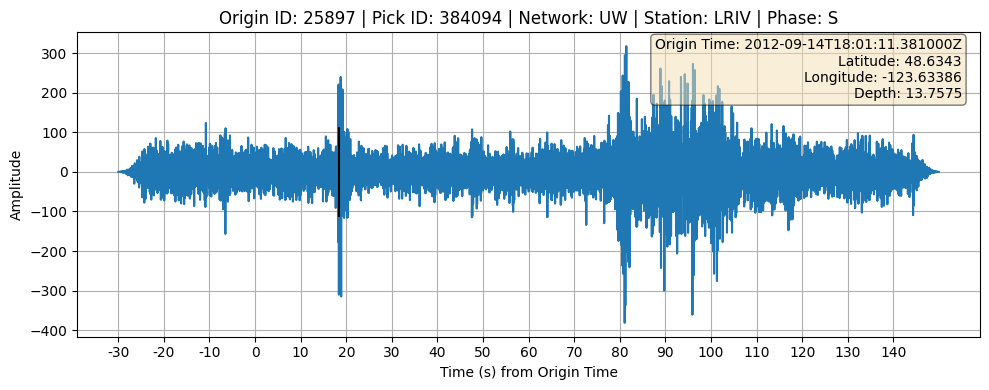

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


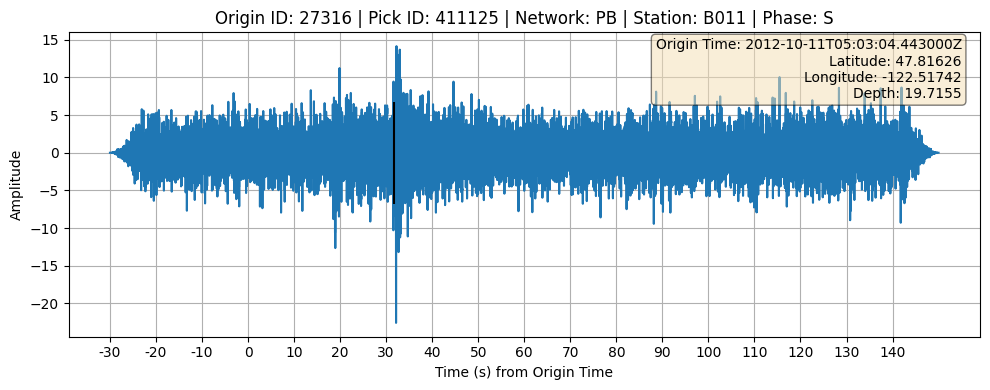

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


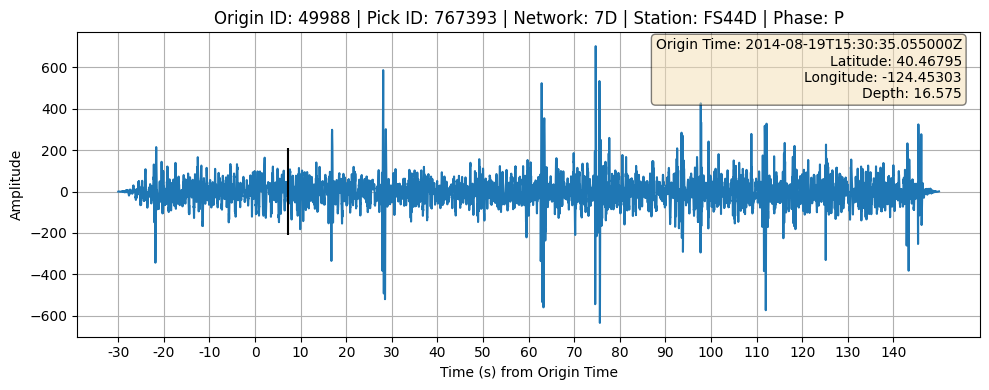

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


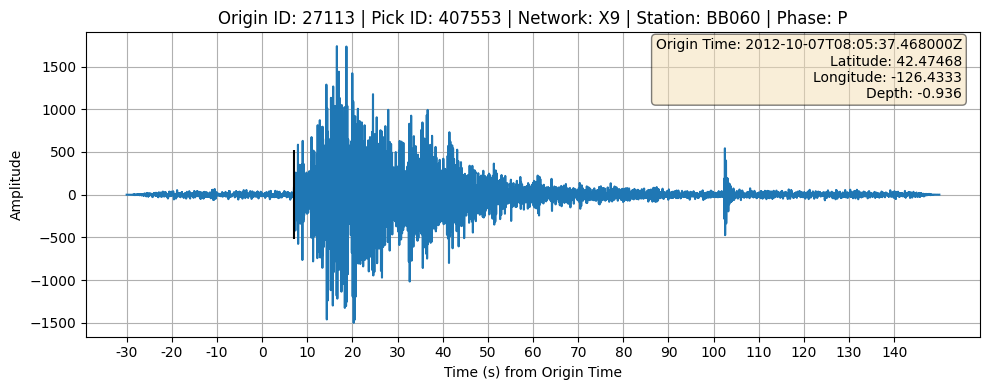

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


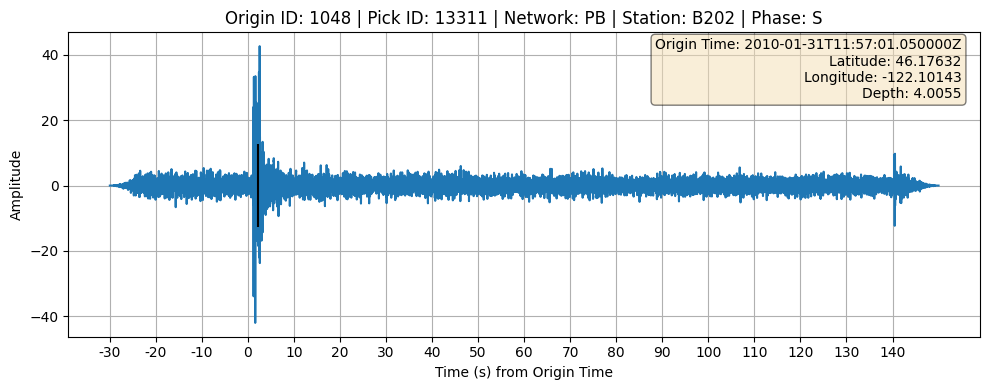

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


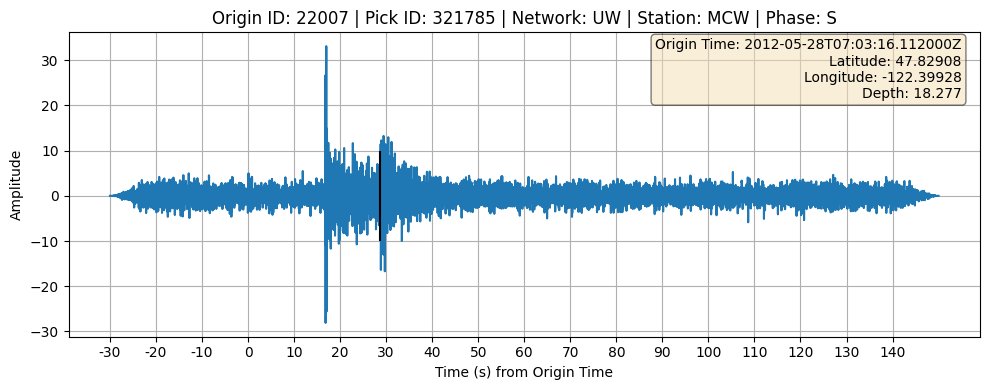

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


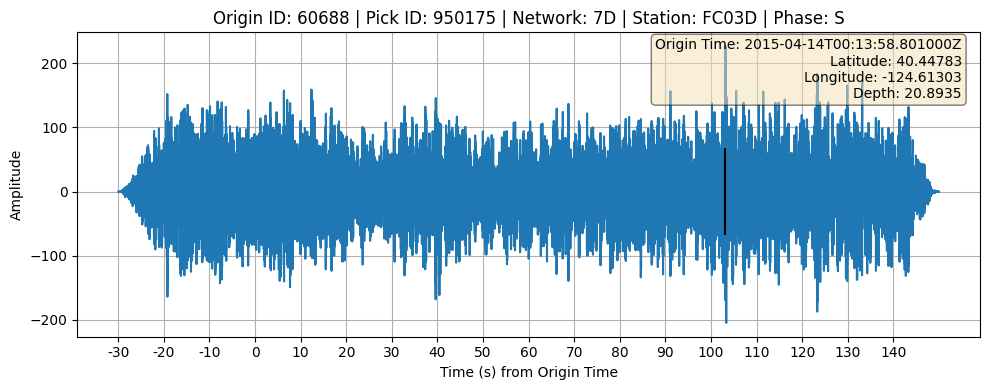

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


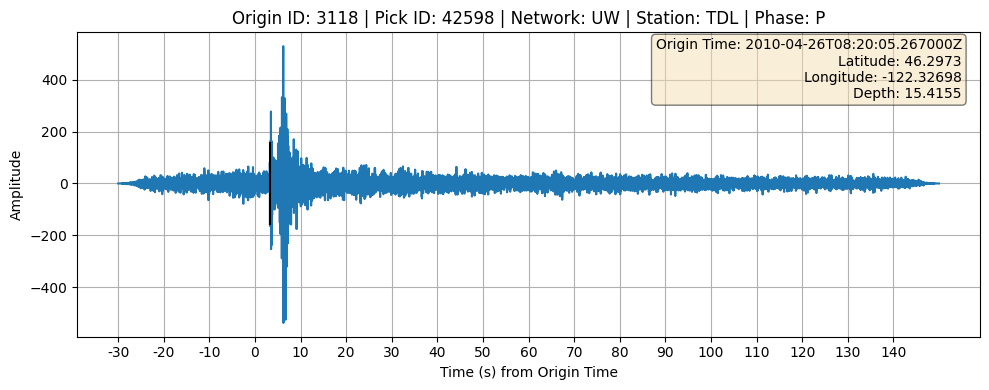

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


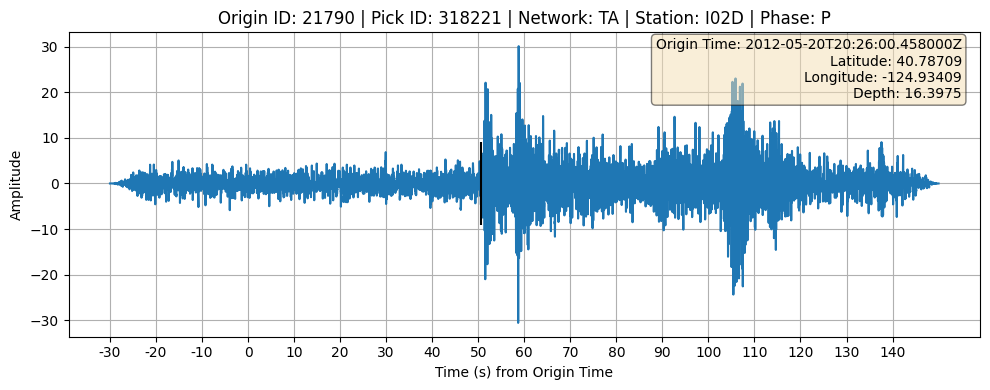

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


No Vertical Component Data Present at NC.KSM with HHZ, BHZ or EHZ channels at 2013-05-18T17:05:52.097700Z. Skipping


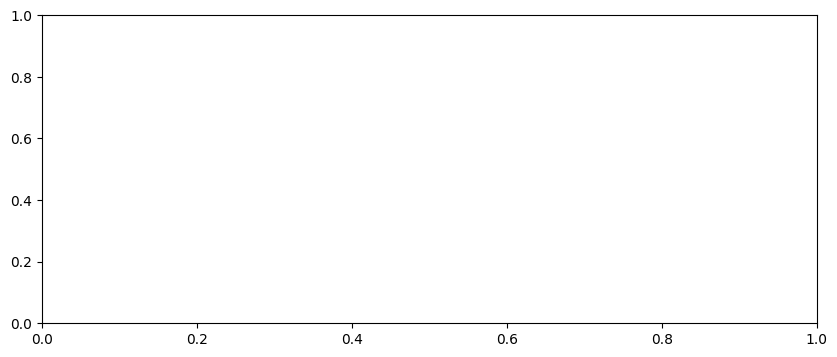

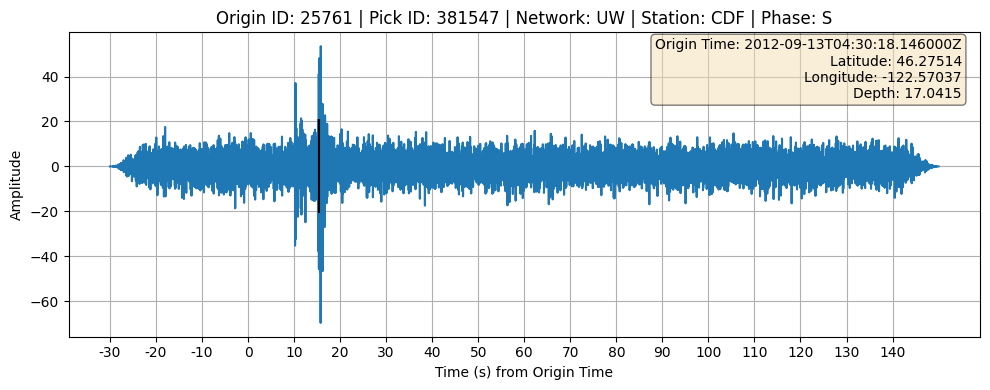

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


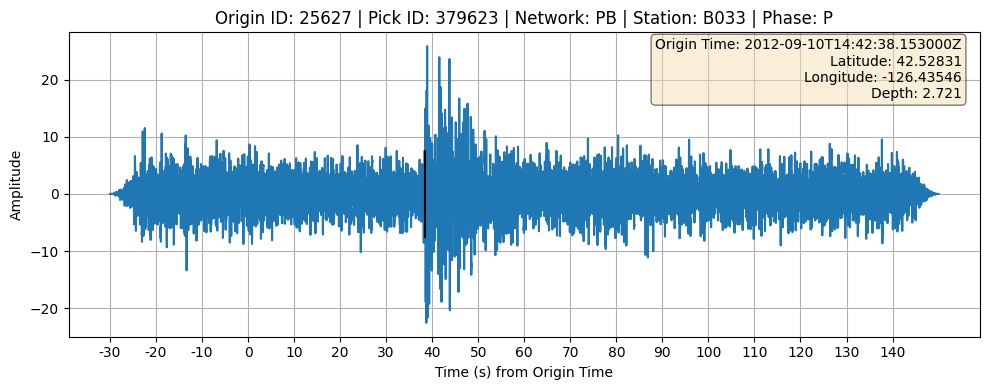

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


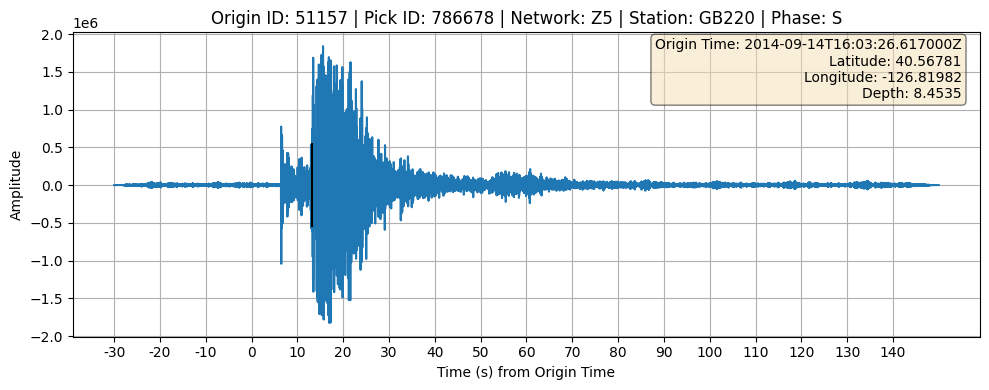

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


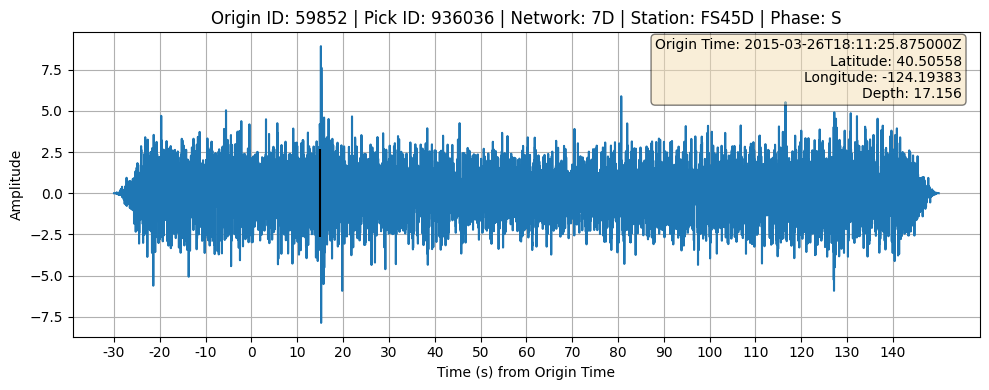

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


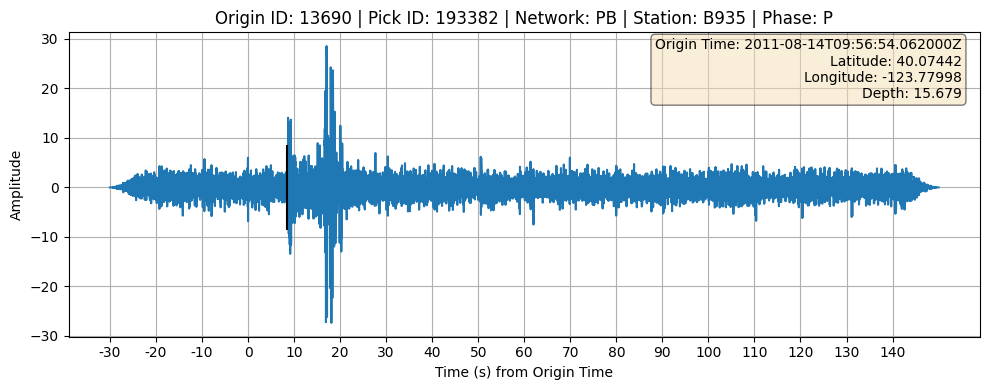

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


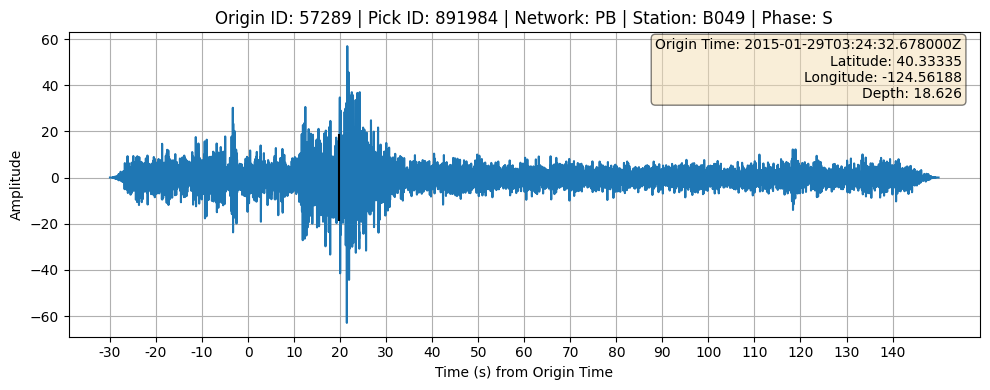

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


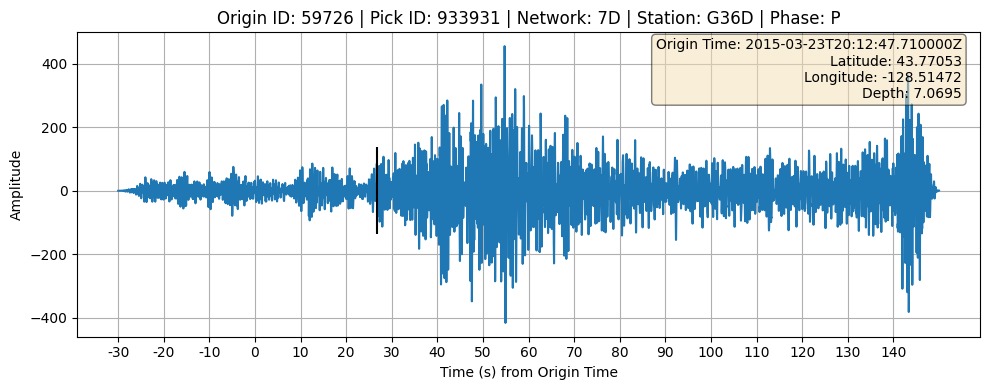

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


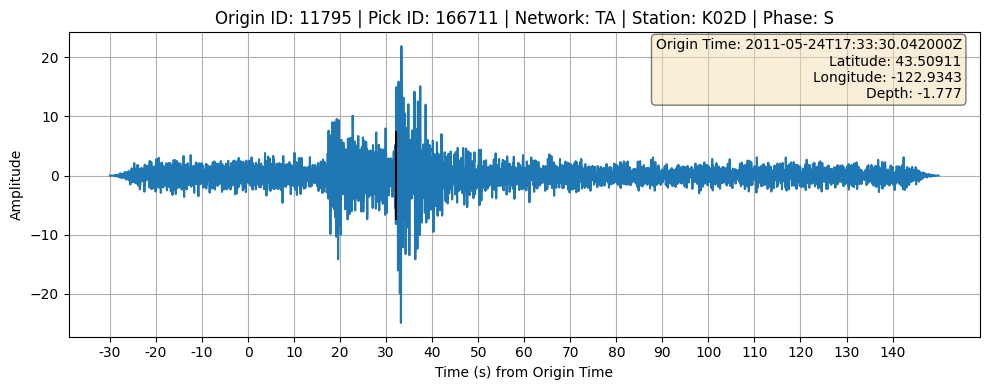

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


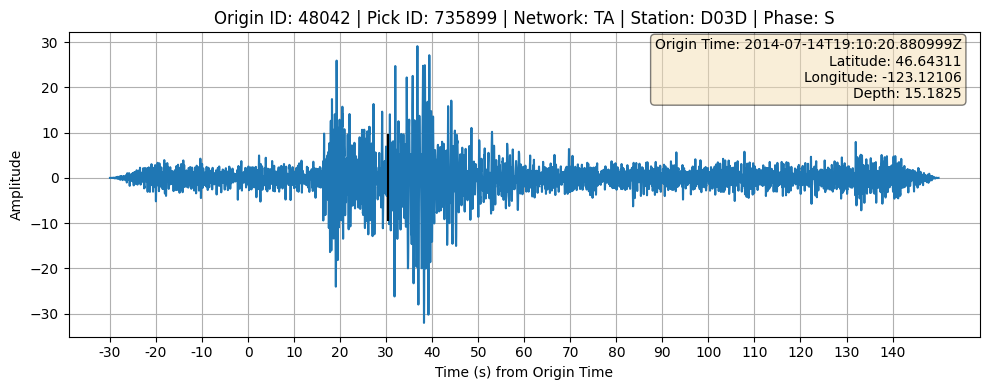

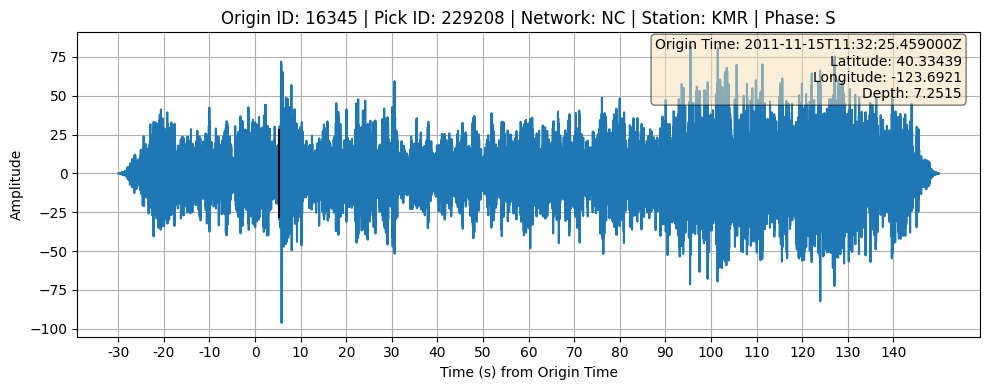

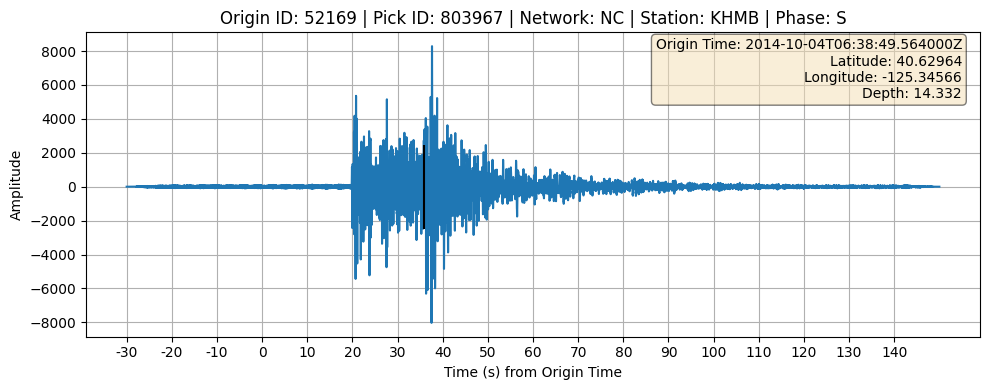

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


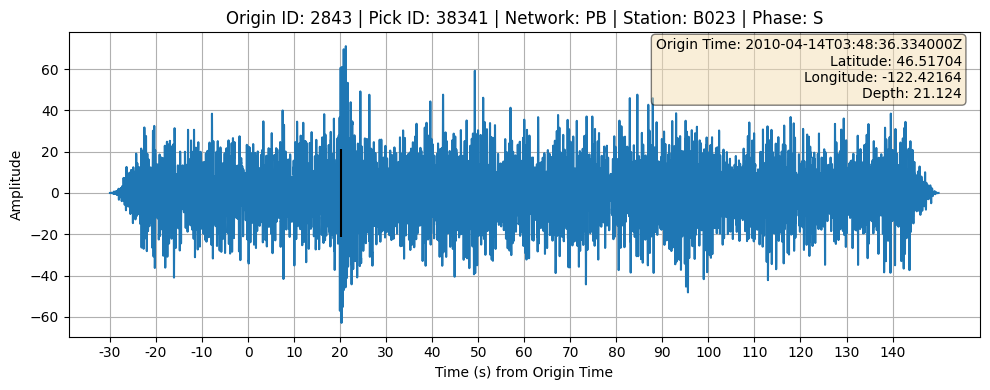

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


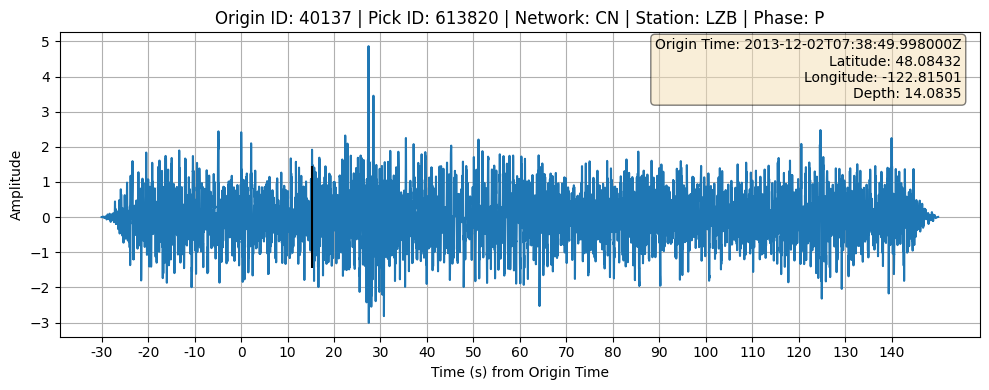

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


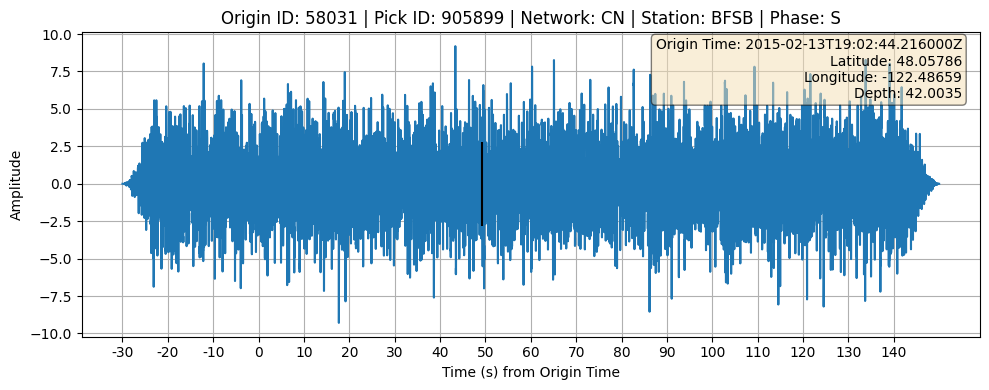

PNWstore | WARNING | Missing mount for year 2023 at /auto/pnwstore1-wd09


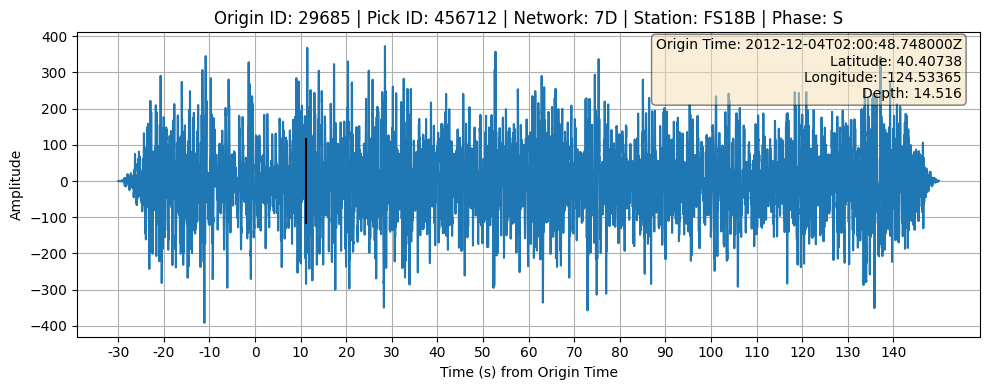

No Vertical Component Data Present at NC.KSM with HHZ, BHZ or EHZ channels at 2012-02-04T19:35:21.027700Z. Skipping


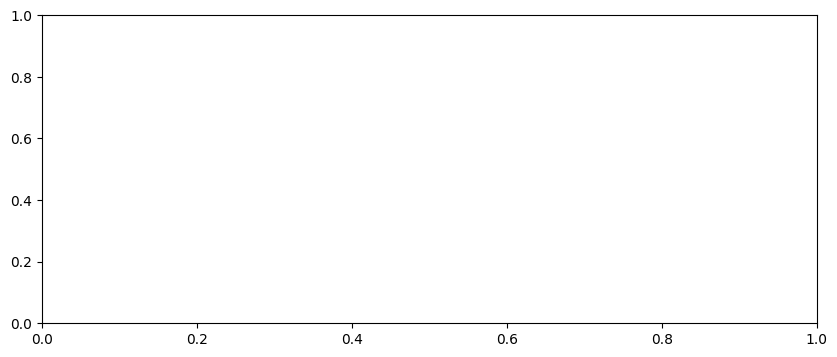

In [7]:
plot_waveforms_for_picks(assigned_picks_df, path_plots, window_before, window_after, n_picks, source, scaling_factor_vline)